In [22]:
# importing Qiskit
from qiskit_aer import AerSimulator 
from qiskit import QuantumCircuit

# import basic plot tools

from qiskit.visualization import plot_histogram

In [23]:
def simon_oracle(b):
    """returns a Simon oracle for bitstring b"""
    b = b[::-1] # reverse b for easy iteration
    n = len(b)
    qc = QuantumCircuit(n*2)
    # Do copy; |x>|0> -> |x>|x>
    for q in range(n):
        qc.cx(q, q+n)
    if '1' not in b:
        return qc  # 1:1 mapping, so just exit
    i = b.find('1') # index of first non-zero bit in b
    # Do |x> -> |s.x> on condition that q_i is 1
    for q in range(n):
        if b[q] == '1':
            qc.cx(i, (q)+n)
    return qc

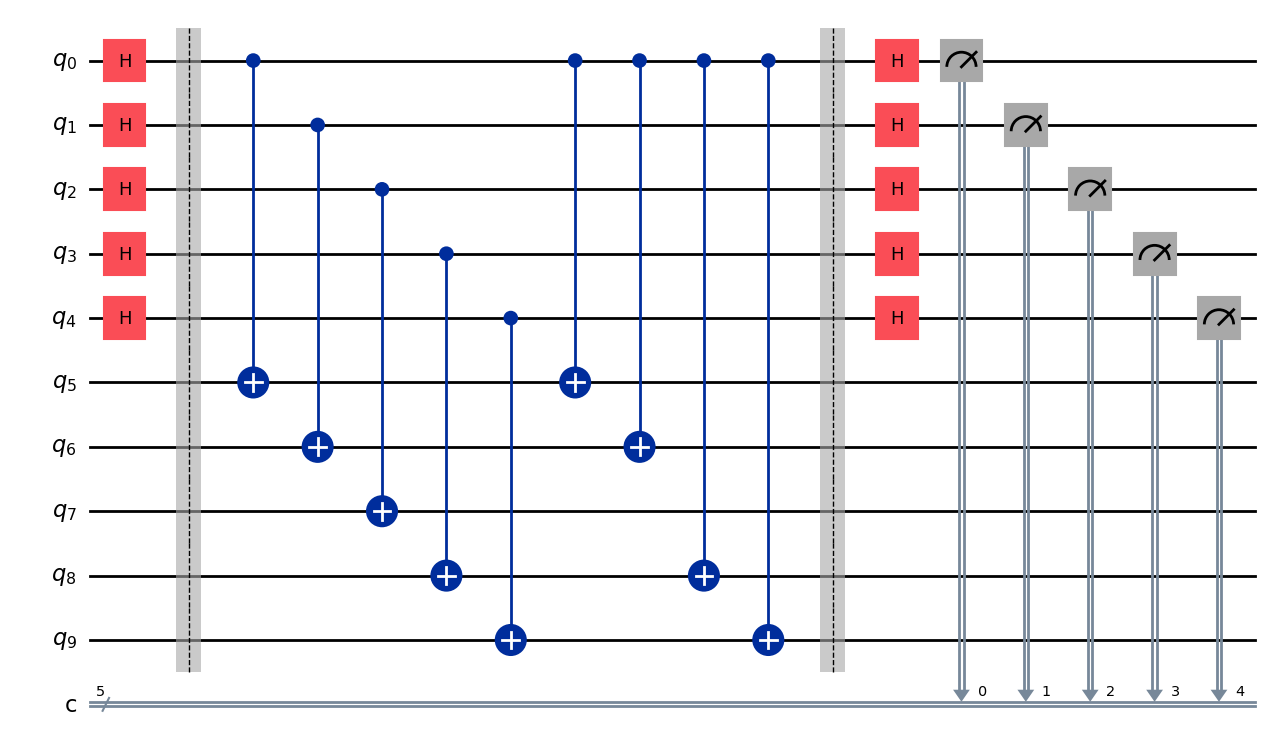

In [24]:
b = '11011'

n = len(b)
simon_circuit = QuantumCircuit(n*2, n)

# Apply Hadamard gates before querying the oracle
simon_circuit.h(range(n))

# Apply barrier for visual separation
simon_circuit.barrier()

simon_circuit = simon_circuit.compose(simon_oracle(b))

# Apply barrier for visual separation
simon_circuit.barrier()

# Apply Hadamard gates to the input register
simon_circuit.h(range(n))

# Measure qubits
simon_circuit.measure(range(n), range(n))

display(simon_circuit.draw('mpl'))

Measurement results (2000 shots):
{'10110': 130, '11111': 131, '10010': 117, '00011': 128, '01010': 127, '01001': 128, '00100': 117, '11100': 115, '10101': 138, '00000': 107, '11000': 128, '10001': 130, '00111': 129, '01101': 142, '01110': 118, '11011': 115}


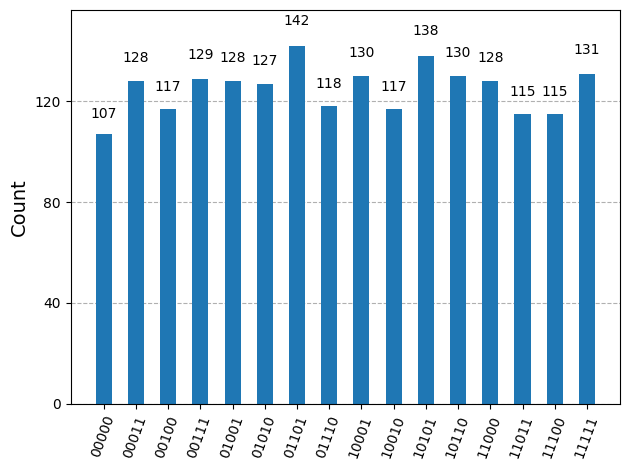

In [25]:

sim = AerSimulator()
result = sim.run(simon_circuit, shots=2000).result()
counts = result.get_counts()
print("Measurement results (2000 shots):")
print(counts)
plot_histogram(counts)

In [26]:
# Calculate the dot product of the results
def bdotz(b, z):
    accum = 0
    for i in range(len(b)):
        accum += int(b[i]) * int(z[i])
    return (accum % 2)

for z in counts:
    print( '{}.{} = {} (mod 2)'.format(b, z, bdotz(b,z)) )

11011.10110 = 0 (mod 2)
11011.11111 = 0 (mod 2)
11011.10010 = 0 (mod 2)
11011.00011 = 0 (mod 2)
11011.01010 = 0 (mod 2)
11011.01001 = 0 (mod 2)
11011.00100 = 0 (mod 2)
11011.11100 = 0 (mod 2)
11011.10101 = 0 (mod 2)
11011.00000 = 0 (mod 2)
11011.11000 = 0 (mod 2)
11011.10001 = 0 (mod 2)
11011.00111 = 0 (mod 2)
11011.01101 = 0 (mod 2)
11011.01110 = 0 (mod 2)
11011.11011 = 0 (mod 2)
